In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:
import os
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

from functools import partial
from time import perf_counter

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from flax import nnx

plt.style.use("../../dmri/utils/pyloric.mplstyle")


In [3]:
from dmri.train.utils import load_checkpoint

# checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated_all_3_6_8_128_model_prior")
graphdef, params, state = nnx.split(model, nnx.Param, ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, state)
model.eval()


In [4]:
# Exhaustive MAP scales as 2**mask_dim, so start with a moderate subset.
num_total = 1_000
num_eval = 256

data = jax.vmap(simulator[0])(jax.random.split(jax.random.PRNGKey(0), num_total))
eval_data = jax.tree_util.tree_map(lambda x: x[:num_eval], data)
jax.tree_util.tree_map(lambda x: x.shape, eval_data)


{'acq': acquisition_scheme(bvals=(256, 105), bvecs=(256, 105, 3), delta=0.0106, Delta=0.0431),
 'mask_prior': (256, 1),
 'model_mask': (256, 12),
 'theta': (256, 51),
 'x': (256, 105)}

In [5]:
mask_dim = int(eval_data["model_mask"].shape[-1])
num_masks = 2 ** mask_dim
print(f"mask_dim = {mask_dim}, exhaustive reference uses {num_masks} masks")

def enumerate_model_masks(mask_dim):
    idx = jnp.arange(2 ** mask_dim, dtype=jnp.uint32)
    bit_ids = jnp.arange(mask_dim, dtype=jnp.uint32)
    return ((idx[:, None] >> bit_ids[None, :]) & 1).astype(jnp.bool_)

all_masks = enumerate_model_masks(mask_dim)

@jax.jit
def score_mask_single(model_mask, example):
    return model.log_prob_mask(
        model_mask,
        acq=example["acq"],
        x=example["x"],
        mask_prior=example["mask_prior"],
    )

@jax.jit
def exact_map_single(example):
    log_probs = jax.vmap(lambda model_mask: score_mask_single(model_mask, example))(all_masks)
    safe_log_probs = jnp.where(jnp.isfinite(log_probs), log_probs, -jnp.inf)
    best_idx = jnp.argmax(safe_log_probs)
    best_mask = all_masks[best_idx]
    return best_mask

exact_map_mask = jax.vmap(exact_map_single)(eval_data)
exact_logq = jax.vmap(score_mask_single)(exact_map_mask, eval_data)
exact_map_mask.shape, exact_logq.shape


mask_dim = 12, exhaustive reference uses 4096 masks


W0328 06:52:47.807851 3986965 hlo_rematerialization.cc:3204] Can't reduce memory use below 56.41GiB (60574545971 bytes) by rematerialization; only reduced to 58.52GiB (62830679656 bytes), down from 58.58GiB (62899098897 bytes) originally


((256, 12), (256,))

In [6]:
@partial(jax.jit, static_argnames=("method", "num_samples", "beam_width", "temperature", "seed"))
def run_map_method(
    data,
    *,
    method="best_of_n",
    num_samples=128,
    beam_width=8,
    temperature=1.0,
    seed=0,
):
    keys = jax.random.split(jax.random.PRNGKey(seed), data["x"].shape[0])
    pred_mask = jax.vmap(
        lambda key, acq, x, mask_prior: model.map_model_mask(
            key,
            acq=acq,
            x=x,
            mask_prior=mask_prior,
            method=method,
            num_samples=num_samples,
            beam_width=beam_width,
            temperature=temperature,
        )
    )(keys, data["acq"], data["x"], data["mask_prior"])

    pred_logq = jax.vmap(score_mask_single)(pred_mask, data)
    return pred_mask, pred_logq

methods = {
    "best_of_128_temp0.5": dict(method="best_of_n", num_samples=128, temperature=1.0, seed=0),
    "best_of_128_temp0.3": dict(method="best_of_n", num_samples=128, temperature=0.5, seed=1),
    "best_of_128_temp0.1": dict(method="best_of_n", num_samples=128, temperature=0.1, seed=2),
    "beam_search_16": dict(method="beam_search", beam_width=16, temperature=1.0, seed=3),
    "beam_search_32": dict(method="beam_search", beam_width=32, temperature=1.0, seed=4),
}

method_labels = {
    "best_of_128_temp0.5": "BoN (t=1.0)",
    "best_of_128_temp0.3": "BoN (t=0.5)",
    "best_of_128_temp0.1": "BoN (t=0.1)",
    "beam_search_16": "Beam (16)",
    "beam_search_32": "Beam (32)",
}

results = {name: run_map_method(eval_data, **cfg) for name, cfg in methods.items()}
list(results)


['best_of_128_temp0.5',
 'best_of_128_temp0.3',
 'best_of_128_temp0.1',
 'beam_search_16',
 'beam_search_32']

In [7]:
single_eval_data = jax.tree_util.tree_map(lambda x: x[:1], eval_data)
timing_repeats = 20
timing_rows = []

for name, cfg in methods.items():
    compiled_out = run_map_method(single_eval_data, **cfg)
    jax.tree_util.tree_map(lambda x: x.block_until_ready(), compiled_out)

    start = perf_counter()
    for _ in range(timing_repeats):
        out = run_map_method(single_eval_data, **cfg)
        jax.tree_util.tree_map(lambda x: x.block_until_ready(), out)
    elapsed = perf_counter() - start

    avg_ms = 1e3 * elapsed / timing_repeats
    timing_rows.append((name, avg_ms))
    print(f"{name:>18} | avg wall clock for one instance: {avg_ms:.3f} ms")


best_of_128_temp0.5 | avg wall clock for one instance: 6.191 ms
best_of_128_temp0.3 | avg wall clock for one instance: 6.210 ms
best_of_128_temp0.1 | avg wall clock for one instance: 6.194 ms
    beam_search_16 | avg wall clock for one instance: 4.389 ms
    beam_search_32 | avg wall clock for one instance: 4.638 ms


In [8]:
# The exact reference cannot be beaten in theory.
# Use two definitions, matching the conv notebook layout:
# 1) success rate is measured directly against the exact reference.
# 2) the gap plot uses the exact reference score and is clipped at zero for numerical stability.
gap_tol = 1e-3
gap_plot_floor = 1e-10

method_names = list(methods)
display_names = [method_labels[name] for name in method_names]
gap_data = []
gap_plot_data = []
success_rates = []

exact_logq_np = np.asarray(exact_logq)
for name in method_names:
    pred_logq_np = np.asarray(results[name][1])
    raw_gap = exact_logq_np - pred_logq_np
    clipped_gap = np.maximum(raw_gap, 0.0)
    success = np.isfinite(pred_logq_np) & (pred_logq_np >= exact_logq_np - gap_tol)

    gap_data.append(clipped_gap)
    gap_plot_data.append(np.maximum(clipped_gap, gap_plot_floor))
    success_rates.append(success.mean())

    print(
        f"{name:>18} | "
        f"mean gap: {clipped_gap.mean():.6f} | "
        f"median gap: {np.median(clipped_gap):.6f} | "
        f"success rate vs exact ref: {success.mean():.3%} | "
        f"largest raw negative: {raw_gap.min():.3e}"
    )

    if raw_gap.min() < -gap_tol:
        print(f"  warning: gap below -{gap_tol:.0e}; check the exact MAP reference for this method.")


best_of_128_temp0.5 | mean gap: 0.003341 | median gap: 0.000009 | success rate vs exact ref: 80.469% | largest raw negative: -9.344e-03
best_of_128_temp0.3 | mean gap: 0.001022 | median gap: 0.000000 | success rate vs exact ref: 83.203% | largest raw negative: -9.344e-03
best_of_128_temp0.1 | mean gap: 0.016220 | median gap: 0.000233 | success rate vs exact ref: 62.109% | largest raw negative: -9.344e-03
    beam_search_16 | mean gap: 0.002209 | median gap: 0.000009 | success rate vs exact ref: 80.859% | largest raw negative: -9.344e-03
    beam_search_32 | mean gap: 0.001097 | median gap: 0.000002 | success rate vs exact ref: 82.422% | largest raw negative: -9.344e-03


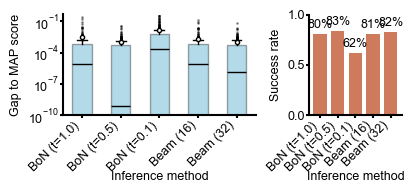

In [43]:
color_gap = "#2596be"
color_success = "#be4d25"

fig, (ax_gap, ax_success) = plt.subplots(
    1,
    2,
    figsize=(4.2, 2.),
    width_ratios=(2.4, 1.15),
)
gap_box = ax_gap.boxplot(
    gap_plot_data,
    tick_labels=display_names,
    showmeans=True,
    patch_artist=True,
    boxprops=dict(facecolor=color_gap, alpha=0.35, edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black"),
    meanprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=3),
    flierprops=dict(marker=".", markersize=2, markerfacecolor="black", markeredgecolor="black", alpha=0.35),
)
ax_gap.set_ylabel("Gap to MAP score")
ax_gap.set_xlabel("Inference method", labelpad=-2)
ax_gap.set_yscale("log")
ax_gap.set_ylim(gap_plot_floor, max(gap_plot_floor * 10, max(np.max(gaps) for gaps in gap_plot_data) * 1.15))
for label in ax_gap.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment("right")
    # Move the tick labels to the right by adjusting the labelpad
    #label.set_position((label.get_position()[0] - 1.5, label.get_position()[1]))

bars = ax_success.bar(display_names, success_rates, color=color_success, alpha=0.75, width=0.75)
ax_success.set_ylabel("Success rate")
ax_success.set_xlabel("Inference method", labelpad=-2)
ax_success.set_ylim(0.0, 1.0)
ax_success.set_yticks([0.0, 0.5, 1.0])
for label in ax_success.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment("right")
    # Move the tick labels to the right by adjusting the labelpad
    #label.set_position((label.get_position()[0] - 0.02, label.get_position()[1]))
for bar, rate in zip(bars, success_rates):
    ax_success.text(
        bar.get_x() + bar.get_width() / 2,
        min(rate + 0.03, 0.98),
        f"{rate:.0%}",
        ha="center",
        va="bottom",
    )

for ax in (ax_gap, ax_success):
    ax.tick_params(length=2, pad=1)

plt.tight_layout(w_pad=0.8)
plt.savefig("map_estimation_gap.png", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("map_estimation_gap.svg",  bbox_inches="tight", transparent=True)
